# 03 — So sánh kiến trúc mô hình: Phát hiện STEMI

**Dự án ACS-ECG-AI (Vinmec)** · **Bài toán 2** — phát hiện nhồi máu cơ tim có ST chênh lên (STEMI)

Notebook này huấn luyện **mười kiến trúc 1D CNN/Transformer khác nhau** trên **cùng một** pipeline
tiền xử lý, **cùng một** phép chia train/val theo bệnh nhân và **cùng một** seed — nên chênh lệch
kết quả giữa chúng phản ánh đúng kiến trúc chứ không phải may rủi của dữ liệu. Sau khi train xong,
notebook **hợp nhất xác suất bằng ensemble kiểu WBF** (mỗi model là một nguồn xác suất, trọng số
theo AUROC validation của chính nó) để xem có tăng được hiệu năng so với model tốt nhất đơn lẻ
không.

Chỉ dùng **ACS-ECG Dataset 2026** (Du et al., *Sci Data* 13:1009, 2026) — không trộn PTB-XL như
`05_stemi_ensemble_ptbxl.ipynb`, để giữ nhãn STEMI hoàn toàn đúng nghĩa (xác nhận qua DSA), không
lẫn nhãn proxy.

| mô hình | ý tưởng chính |
|---|---|
| **PlainCNN** | 4 khối Conv-BN-ReLU-MaxPool xếp chồng. Mốc sàn: nếu mô hình phức tạp không thắng được cái này thì độ phức tạp thêm vào là vô ích. |
| **ResNet1D** | Thêm skip connection để mạng sâu vẫn học được. Đây là mô hình dùng ở notebook `01_stemi_classifier.ipynb`. |
| **InceptionTime1D** | Mỗi khối nhìn tín hiệu bằng nhiều độ dài kernel song song (39/19/9), nên bắt được cả sóng nhanh (QRS) lẫn biến thiên chậm (đoạn ST). |
| **CNN+BiLSTM** | CNN rút đặc trưng cục bộ, rồi LSTM hai chiều mô hình hoá quan hệ theo thời gian giữa các nhịp. |
| **SEResNet1D** | ResNet1D + squeeze-excitation sau mỗi khối — model tự học cách cân trọng các kênh đặc trưng. |
| **Transformer1D** | Cắt tín hiệu thành patch theo thời gian, self-attention — bắt phụ thuộc dài hạn mà CNN thuần khó nắm. |
| **TCN1D** | Conv1D giãn nở (dilation) nhiều tầng — receptive field rộng mà vẫn giữ độ phân giải thời gian cao. |
| **XResNet1D** | Biến thể ResNet1D: stem sâu (3 conv nhỏ xếp chồng), nhánh tắt AvgPool+1×1 conv, activation SiLU. |
| **ConvNeXtV2_1D** | Khối depthwise-conv + LayerNorm + MLP mở rộng + Global Response Normalization — bản 1D của ConvNeXt V2. |
| **AiTiAMI** *(tái hiện)* | Lấy cảm hứng từ Lee *et al.*, *Eur Heart J* 2025 (ehaf004, nghiên cứu **ROMIAE**) — mô tả AI-ECG thương mại "AiTiAMI v1.00.00" của Medical AI Co. là "dựa trên residual neural network", đầu vào 500Hz 12 chuyển đạo. **Bài báo không công bố kiến trúc chi tiết hay trọng số** (sản phẩm thương mại) — đây là một ResNet1D sâu/rộng hơn, kernel hẹp hơn, head avg+max-pool, đại diện hợp lý cho mô tả đó chứ **không phải model gốc**. Xem cảnh báo đầy đủ ở mục 12. |

Notebook tự chứa, chạy được trên **Google Colab** lẫn máy cá nhân.
Bài toán còn lại được xử lý ở một notebook riêng — cố ý không gộp chung để mỗi bài toán có
kết luận độc lập.

## 1. Cài thư viện

Chỉ cài `wfdb` nếu môi trường chưa có. Trên Colab cần cài lại mỗi phiên (~10 giây).

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("wfdb") is None:
    print("Đang cài wfdb ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wfdb"], check=True)

import wfdb

print("wfdb", wfdb.__version__)

wfdb 4.3.1


## 2. Cấu hình

Notebook chạy được trên **Google Colab** và **máy cá nhân**, tự nhận diện môi trường.
Chỉ cần sửa đúng một chỗ:

- **Colab** → `DRIVE_PROJECT` (tên thư mục trên Drive chứa `datasets.zip`)
- **Máy cá nhân** → `LOCAL_DATA_ROOT`

Ngoài ra đổi `RUN_MODE` khi muốn chuyển từ chạy thử sang chạy thật.

**Thư mục `outputs/` chỉ giữ hai thứ:** checkpoint mô hình và cache tín hiệu. Hình và bảng số
đều hiển thị ngay trong notebook nên không ghi ra file nữa.

Trên Colab, cache đặt ở `/content` (nhanh, mất khi hết phiên) và được sao lưu lên Drive để phiên
sau khỏi tiền xử lý lại; checkpoint ghi thẳng lên Drive để không mất khi đứt phiên.

In [2]:
import os
from pathlib import Path

import torch

# ===================== CHẾ ĐỘ CHẠY =====================
RUN_MODE = "full"        # "debug" = 200 bản ghi / 3 epoch  |  "full" = toàn bộ / 30 epoch

# ===================== ĐƯỜNG DẪN =======================
IS_COLAB = importlib.util.find_spec("google.colab") is not None

if IS_COLAB:
    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")   # <<< SỬA nếu đặt tên khác
    DRIVE_DATA_ZIP = DRIVE_PROJECT / "datasets.zip"             # <<< SỬA nếu tên zip khác
    DATA_ROOT = Path("/content/datasets")      # giải nén ra đĩa local cho nhanh
    WORK_DIR = Path("/content/work")           # tạm, mất khi hết phiên
    PERSIST_DIR = DRIVE_PROJECT / "outputs"    # bền qua các phiên
else:
    LOCAL_DATA_ROOT = r"C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets"                    # <<< SỬA khi chạy máy cá nhân
    DATA_ROOT = Path(LOCAL_DATA_ROOT)
    WORK_DIR = DATA_ROOT.parent / "outputs"
    PERSIST_DIR = WORK_DIR

CACHE_DIR = WORK_DIR / "cache"                     # cache tín hiệu (sinh lại được)
MODEL_DIR = PERSIST_DIR / "models" / "stemi_compare"  # checkpoint (không được mất)
DRIVE_CACHE_DIR = (PERSIST_DIR / "cache") if IS_COLAB else None

# ===================== THAM SỐ =========================
SEED = 42
FS, SIGNAL_LEN, NUM_LEADS = 500, 5000, 12      # 12 chuyển đạo × 10 giây @ 500 Hz
BP_LOW, BP_HIGH, BP_ORDER = 0.5, 40.0, 3       # bandpass Butterworth
VAL_SIZE = 0.15                                 # chia theo bệnh nhân 85/15
LR, WEIGHT_DECAY = 1e-3, 1e-4
EARLY_STOP_PATIENCE, LR_PATIENCE = 10, 5
ECE_BINS = 10
TARGET_LABEL = "STEMI"
CLASS_NAME = "STEMI"

# Số bản ghi trong paper (tính trên toàn bộ 19.955); ta chỉ có nhãn cho 90% nên dung sai ±10%
PAPER_COUNTS = {"STEMI": 1513, "NSTEMI": 1274, "UA": 6197}
SANITY_TOL = 0.10

# ===================== SUY RA ==========================
GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if GPU_AVAILABLE else "cpu")
DEBUG_LIMIT = 200
EPOCHS = 3 if RUN_MODE == "debug" else 30
BATCH_SIZE = 8 if RUN_MODE == "debug" else (64 if GPU_AVAILABLE else 16)
USE_AMP = GPU_AVAILABLE

print("Môi trường :", "Google Colab" if IS_COLAB else "máy cá nhân")
print("Thiết bị   :", DEVICE)
print("Chế độ     :", RUN_MODE, f"({EPOCHS} epoch, batch {BATCH_SIZE})")
print("Nhãn đích  :", TARGET_LABEL)

Môi trường : máy cá nhân
Thiết bị   : cuda
Chế độ     : full (30 epoch, batch 64)
Nhãn đích  : STEMI


### 2b. Chuẩn bị dữ liệu

Trên máy cá nhân cell này chỉ tạo thư mục. Trên Colab nó mount Drive (sẽ hiện popup xin quyền —
đây là thao tác thủ công duy nhất), copy `datasets.zip` về `/content` rồi giải nén.

Phải đi vòng qua zip vì bộ dữ liệu có **59.867 file**, mà Drive tính mỗi lần mở file là một lệnh
gọi mạng — đọc trực tiếp từ Drive sẽ chậm hơn hàng chục lần.

In [3]:
import shutil
import time
import zipfile


def _locate_data_root(search_root: Path) -> Path:
    """Tìm thư mục thật chứa dữ liệu, chịu được việc zip có bọc thêm lớp thư mục."""
    wanted = {"csv", "row_data", "raw_data", "med_data"}
    best, best_score = search_root, -1
    for cand in [search_root, *[p for p in search_root.rglob("*") if p.is_dir()]]:
        try:
            names = {c.name.lower() for c in cand.iterdir() if c.is_dir()}
        except OSError:
            continue
        if len(names & wanted) > best_score:
            best, best_score = cand, len(names & wanted)
        if best_score >= 2:
            break
    return best


def stage_colab_data() -> Path:
    marker = DATA_ROOT / ".staged_ok"
    if marker.exists():
        real = Path(marker.read_text().strip())
        print("Dữ liệu đã sẵn sàng:", real)
        return real

    if not DRIVE_DATA_ZIP.exists():
        có_gì = sorted(p.name for p in DRIVE_PROJECT.iterdir())[:40]
        raise FileNotFoundError(
            f"Không thấy {DRIVE_DATA_ZIP}\nTrong {DRIVE_PROJECT} hiện có: {có_gì}"
        )

    local_zip = Path("/content/_dataset.zip")
    size = DRIVE_DATA_ZIP.stat().st_size
    if not (local_zip.exists() and local_zip.stat().st_size == size):
        print(f"Copy zip {size / 1024 ** 3:.2f} GB từ Drive ...")
        t0 = time.time()
        shutil.copy2(DRIVE_DATA_ZIP, local_zip)
        print(f"  {time.time() - t0:.0f}s")

    extract_to = Path("/content/_extract")
    if extract_to.exists():
        shutil.rmtree(extract_to)
    print("Giải nén ...")
    t0 = time.time()
    with zipfile.ZipFile(local_zip) as zf:
        zf.extractall(extract_to)
    print(f"  {time.time() - t0:.0f}s")

    real = _locate_data_root(extract_to)
    real.mkdir(parents=True, exist_ok=True)
    (real / ".staged_ok").write_text(str(real))
    return real


if IS_COLAB:
    if str(DRIVE_PROJECT).startswith(("http://", "https://", "www.")):
        raise ValueError(
            "DRIVE_PROJECT đang là URL chia sẻ Drive. Phải là đường dẫn sau khi mount:\n"
            '    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")'
        )
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    if not DRIVE_PROJECT.exists():
        my = Path("/content/drive/MyDrive")
        có_gì = sorted(p.name for p in my.iterdir() if p.is_dir())[:40] if my.exists() else []
        raise FileNotFoundError(
            f"Không thấy {DRIVE_PROJECT}\nCác thư mục trong MyDrive: {có_gì}"
        )

for d in [CACHE_DIR, MODEL_DIR] + ([DRIVE_CACHE_DIR] if DRIVE_CACHE_DIR else []):
    d.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    DATA_ROOT = stage_colab_data()

print("DATA_ROOT:", DATA_ROOT, "| tồn tại:", DATA_ROOT.exists())

DATA_ROOT: C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets | tồn tại: True


## 3. Seed & GPU

In [4]:
import random

import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Input cố định (12 × 5000) nên cuDNN chọn thuật toán nhanh nhất một lần rồi giữ nguyên.
# Đánh đổi: epoch đầu chậm hơn vài giây, và kết quả không tái lập chính xác 100%.
torch.backends.cudnn.benchmark = GPU_AVAILABLE

print("torch", torch.__version__, "| GPU:", torch.cuda.get_device_name(0) if GPU_AVAILABLE else "không có")
if IS_COLAB and not GPU_AVAILABLE:
    print("\n" + "!" * 70)
    print("!! COLAB KHÔNG CÓ GPU -> Runtime > Change runtime type > GPU, rồi Run all lại.")
    print("!" * 70)

torch 2.11.0+cu128 | GPU: NVIDIA RTX 2000 Ada Generation Laptop GPU


## 4. Dữ liệu và nhãn

Nhãn chỉ có trong `train.csv` (phần 90% chính thức). `test.csv` là tập test ẩn, không có cột nhãn
và **không bao giờ được đọc** trong notebook này.

Sanity check đối chiếu số ca với paper. Dung sai ±10% chứ không phải ±2%, vì số của paper tính trên
toàn bộ 19.955 bản ghi còn ta chỉ đếm được trên 90% có nhãn.

In [5]:
import pandas as pd

pd.set_option("display.width", 200)


def find_dir(root: Path, names):
    wanted = {n.lower() for n in names}
    for c in sorted(root.iterdir()):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    for c in root.rglob("*"):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    return None


RAW_DIR = find_dir(DATA_ROOT, ["row_data", "raw_data"])
CSV_DIR = find_dir(DATA_ROOT, ["CSV", "csv"])
assert RAW_DIR and CSV_DIR, f"Không thấy row_data/ hoặc CSV/ trong {DATA_ROOT}"

df_raw = pd.read_csv(CSV_DIR / "train.csv")
df_raw["record_stem"] = df_raw["ecg_row_record"].astype(str).str.replace(".dat", "", regex=False)

COL_PATIENT, COL_AGE, COL_GENDER = "Patient_id", "age", "gender"
print(f"{len(df_raw):,} bản ghi | {df_raw[COL_PATIENT].nunique():,} bệnh nhân | "
      f"{len(list(RAW_DIR.glob('*.dat'))):,} file .dat")

# --- Sanity check ---
print(f"\n{'nhãn':<8}{'đếm được':>11}{'paper':>9}{'lệch':>9}")
ok_all = True
for name, expected in PAPER_COUNTS.items():
    got = int(df_raw[name].sum())
    delta = (got - expected) / expected
    ok_all &= abs(delta) <= SANITY_TOL
    print(f"{name:<8}{got:>11,}{expected:>9,}{delta:>8.1%}   {'OK' if abs(delta) <= SANITY_TOL else 'LỆCH'}")
if not ok_all:
    print("\n!! CẢNH BÁO: số ca lệch quá ±10% so với paper — kiểm tra lại nguồn dữ liệu.")

# --- Nhãn đích ---
df_all = df_raw.copy()
df_all[TARGET_LABEL] = df_all["STEMI"].astype(int)
print("Nhãn = cột STEMI (lấy trực tiếp)")

n_pos = int(df_all[TARGET_LABEL].sum())
print(f"\nNhãn {TARGET_LABEL}: {n_pos:,} dương ({n_pos / len(df_all):.2%}) / "
      f"{len(df_all) - n_pos:,} âm")

17,960 bản ghi | 17,018 bệnh nhân | 19,955 file .dat

nhãn       đếm được    paper     lệch
STEMI         1,442    1,513   -4.7%   OK
NSTEMI        1,235    1,274   -3.1%   OK
UA            6,213    6,197    0.3%   OK
Nhãn = cột STEMI (lấy trực tiếp)

Nhãn STEMI: 1,442 dương (8.03%) / 16,518 âm


## 5. Lấy mẫu khi chạy thử

Ở `RUN_MODE="debug"` lấy 200 bản ghi **stratified** theo nhãn, để tập mẫu không rơi vào toàn 0
hoặc toàn 1 (khi đó mọi metric sẽ vô định).

In [6]:
from sklearn.model_selection import train_test_split

if RUN_MODE == "debug" and len(df_all) > DEBUG_LIMIT:
    df, _ = train_test_split(df_all, train_size=DEBUG_LIMIT,
                             stratify=df_all[TARGET_LABEL], random_state=SEED)
    df = df.reset_index(drop=True)
else:
    df = df_all.reset_index(drop=True)

n_pos = int(df[TARGET_LABEL].sum())
print(f"Dùng {len(df):,} bản ghi | {n_pos:,} dương ({n_pos / len(df):.2%})")
assert 0 < n_pos < len(df), "Tập chỉ có một lớp — không train được."

Dùng 17,960 bản ghi | 1,442 dương (8.03%)


## 7. Tiền xử lý và cache

Với mỗi bản ghi: đọc WFDB → NaN→0 → cắt/đệm về đúng 5000 mẫu → bandpass Butterworth 0,5–40 Hz
(`filtfilt`, zero-phase). **Chuẩn hoá z-score làm sau**, ở bước 9, với mean/std tính riêng trên tập
train để không rò rỉ thống kê của val sang train.

Lọc lại toàn bộ ở mỗi epoch là nút thắt cổ chai, nên tín hiệu đã lọc được cache **một lần** vào
memmap `float16` (~2,2 GB cho 17.960 bản ghi). Cache nối tiếp được nếu bị ngắt giữa chừng, và trên
Colab được sao lưu lên Drive.

> **Hai bản ghi lỗi trong dữ liệu gốc.** `03228` và `14262` có file `.dat` chỉ chứa 3.500/5.000 mẫu,
> khiến `wfdb.rdrecord()` báo lỗi. Hàm dưới bắt lỗi đó, đọc phần thực có rồi để bước zero-pad bù nốt.

In [7]:
import hashlib
import json

from scipy.signal import butter, filtfilt

_B, _A = butter(BP_ORDER, [BP_LOW / (FS / 2), BP_HIGH / (FS / 2)], btype="band")
TRUNCATED = []


def load_signal(stem: str) -> np.ndarray:
    path = str(RAW_DIR / stem)
    try:
        rec = wfdb.rdrecord(path)
    except ValueError:                     # .dat ngắn hơn header khai báo
        n_sig = int((RAW_DIR / f"{stem}.hea").read_text().splitlines()[0].split()[1])
        n = (RAW_DIR / f"{stem}.dat").stat().st_size // (n_sig * 2)
        rec = wfdb.rdrecord(path, sampto=n)
        TRUNCATED.append(stem)
    return np.asarray(rec.p_signal, dtype=np.float32).T


def preprocess(sig: np.ndarray) -> np.ndarray:
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    if sig.shape[1] < SIGNAL_LEN:
        sig = np.pad(sig, ((0, 0), (0, SIGNAL_LEN - sig.shape[1])))
    return np.ascontiguousarray(filtfilt(_B, _A, sig[:, :SIGNAL_LEN], axis=1), dtype=np.float32)


records = df["record_stem"].tolist()
_hash = hashlib.md5("|".join(records).encode()).hexdigest()[:8]
CACHE_NPY = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.npy"
CACHE_META = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.meta.json"


def _complete(meta_p: Path, npy_p: Path) -> bool:
    if not (meta_p.exists() and npy_p.exists()):
        return False
    try:
        return json.loads(meta_p.read_text()).get("n_done", 0) >= len(records)
    except (OSError, ValueError):
        return False


def build_cache() -> np.ndarray:
    # Colab: thử lấy lại cache của phiên trước từ Drive
    if DRIVE_CACHE_DIR and not _complete(CACHE_META, CACHE_NPY):
        d_npy, d_meta = DRIVE_CACHE_DIR / CACHE_NPY.name, DRIVE_CACHE_DIR / CACHE_META.name
        if _complete(d_meta, d_npy):
            print(f"Lấy cache từ Drive ({d_npy.stat().st_size / 1024 ** 3:.2f} GB) ...")
            t0 = time.time()
            shutil.copy2(d_npy, CACHE_NPY)
            shutil.copy2(d_meta, CACHE_META)
            print(f"  {time.time() - t0:.0f}s — bỏ qua tiền xử lý")

    if _complete(CACHE_META, CACHE_NPY):
        print("Cache đã đầy đủ:", CACHE_NPY.name)
        return np.load(CACHE_NPY, mmap_mode="r")

    meta = json.loads(CACHE_META.read_text()) if CACHE_META.exists() else {}
    start = int(meta.get("n_done", 0)) if CACHE_NPY.exists() else 0
    if start:
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="r+")
        print(f"Build tiếp từ {start}/{len(records)}")
    else:
        print(f"Build cache {len(records):,} bản ghi "
              f"(~{len(records) * NUM_LEADS * SIGNAL_LEN * 2 / 1024 ** 3:.2f} GB)")
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="w+", dtype=np.float16,
                                        shape=(len(records), NUM_LEADS, SIGNAL_LEN))

    t0 = time.time()
    step = max(1, len(records) // 8)
    for i in range(start, len(records)):
        arr[i] = preprocess(load_signal(records[i])).astype(np.float16)
        if (i + 1) % step == 0 or i + 1 == len(records):
            arr.flush()
            CACHE_META.write_text(json.dumps({"n_done": i + 1}))
            el = max(time.time() - t0, 1e-6)
            done = i + 1 - start
            print(f"  {i + 1:>6,}/{len(records):,}  {done / el:5.0f} rec/s  "
                  f"ETA {(len(records) - i - 1) / (done / el):4.0f}s")
    del arr
    print(f"Xong trong {time.time() - t0:.0f}s")

    if DRIVE_CACHE_DIR:
        print("Sao lưu cache lên Drive ...")
        shutil.copy2(CACHE_NPY, DRIVE_CACHE_DIR / CACHE_NPY.name)
        shutil.copy2(CACHE_META, DRIVE_CACHE_DIR / CACHE_META.name)
    return np.load(CACHE_NPY, mmap_mode="r")


CACHE = build_cache()
print("Cache:", CACHE.shape, CACHE.dtype)
if TRUNCATED:
    print(f"Bản ghi bị cắt ngắn, đã zero-pad: {TRUNCATED}")

Cache đã đầy đủ: sig_full_n17960_c20c6dba.npy
Cache: (17960, 12, 5000) float16


## 9. Chia train/val theo bệnh nhân

Bắt buộc chia theo `Patient_id`: một bệnh nhân có thể có nhiều ECG trong 7 ngày trước DSA, chia theo
bản ghi sẽ khiến cùng một người xuất hiện ở cả train lẫn val.

Stratify ở **cấp bệnh nhân** (lấy `max` nhãn của người đó) — cần thiết vì có bệnh nhân mang nhãn
không đồng nhất giữa các bản ghi của chính mình (xem mục 6).

Ngay sau khi chia, mean/std cho z-score được tính **chỉ trên các bản ghi thuộc train**.

In [8]:
pat = df.groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
strat = pat[TARGET_LABEL] if pat[TARGET_LABEL].value_counts().min() >= 2 else None
pat_tr, pat_va = train_test_split(pat, test_size=VAL_SIZE, stratify=strat, random_state=SEED)

train_idx = df.index[df[COL_PATIENT].isin(set(pat_tr[COL_PATIENT]))].to_numpy()
val_idx = df.index[df[COL_PATIENT].isin(set(pat_va[COL_PATIENT]))].to_numpy()
y = df[TARGET_LABEL].values.astype(np.float32)

assert not (set(pat_tr[COL_PATIENT]) & set(pat_va[COL_PATIENT])), "RÒ RỈ: bệnh nhân ở cả 2 tập"
print("Giao nhau patient_id: RỖNG -> OK\n")

display(pd.DataFrame({
    "tập": ["train", "val"],
    "bệnh nhân": [len(pat_tr), len(pat_va)],
    "bản ghi": [len(train_idx), len(val_idx)],
    "dương": [int(y[train_idx].sum()), int(y[val_idx].sum())],
    "tỷ lệ dương": [f"{y[train_idx].mean():.2%}", f"{y[val_idx].mean():.2%}"],
}))


def norm_stats(idx, chunk=256):
    order = np.sort(np.asarray(idx))
    s = np.zeros(NUM_LEADS)
    ss = np.zeros(NUM_LEADS)
    cnt = 0
    for i in range(0, len(order), chunk):
        b = np.asarray(CACHE[order[i:i + chunk]], dtype=np.float64)
        s += b.sum(axis=(0, 2))
        ss += (b ** 2).sum(axis=(0, 2))
        cnt += b.shape[0] * b.shape[2]
    m = s / cnt
    return m.astype(np.float32), np.sqrt(np.maximum(ss / cnt - m ** 2, 1e-12)).astype(np.float32)


LEAD_MEAN, LEAD_STD = norm_stats(train_idx)
print(f"\nz-score fit trên {len(train_idx):,} bản ghi TRAIN")

Giao nhau patient_id: RỖNG -> OK



,tập,bệnh nhân,bản ghi,dương,tỷ lệ dương
0,train,14465,15264,1225,8.03%
1,val,2553,2696,217,8.05%



z-score fit trên 15,264 bản ghi TRAIN


## 10. Dataset & DataLoader

In [9]:
from torch.utils.data import DataLoader, Dataset


class ECGDataset(Dataset):
    def __init__(self, indices, labels):
        self.indices = np.asarray(indices)
        self.labels = np.asarray(labels, dtype=np.float32)
        self.mean = LEAD_MEAN.reshape(-1, 1)
        self.std = LEAD_STD.reshape(-1, 1)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x = np.asarray(CACHE[self.indices[i]], dtype=np.float32)
        return torch.from_numpy((x - self.mean) / self.std), torch.tensor(self.labels[i])


# Windows tạo worker bằng spawn (mỗi worker nạp lại cả notebook) nên để 0; Linux dùng fork -> 2
NUM_WORKERS = 0 if os.name == "nt" else 2
_extra = dict(persistent_workers=True, prefetch_factor=4) if NUM_WORKERS else {}

train_loader = DataLoader(ECGDataset(train_idx, y[train_idx]), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
val_loader = DataLoader(ECGDataset(val_idx, y[val_idx]), batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)

xb, yb = next(iter(train_loader))
print(f"batch: {tuple(xb.shape)} {xb.dtype} | nhãn {tuple(yb.shape)} | "
      f"{len(train_loader)} batch train, {len(val_loader)} batch val")

batch: (64, 12, 5000) torch.float32 | nhãn (64,) | 239 batch train, 43 batch val


## 11. Hàm tính metric

`compute_metrics` an toàn với tập nhỏ: khi chỉ có một lớp hoặc mẫu số bằng 0, trả `nan` thay vì
ném lỗi hay trả 0 gây hiểu nhầm.

`per_class_report` cho bảng tách riêng **lớp âm tính (0)** và **lớp dương tính (1)** — mỗi lớp có
Precision/Recall/F1/Support riêng, kèm hai dòng trung bình macro và weighted.

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score)

plt.rcParams["figure.dpi"] = 110


def _div(a, b):
    return float(a) / float(b) if b else float("nan")


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob, dtype=np.float64).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    two = len(np.unique(y_true)) == 2
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, y_prob) if two else float("nan"),
        "auprc": average_precision_score(y_true, y_prob) if two else float("nan"),
        "sensitivity": _div(tp, tp + fn), "specificity": _div(tn, tn + fp),
        "ppv": _div(tp, tp + fp), "npv": _div(tn, tn + fn),
        "f1": _div(2 * tp, 2 * tp + fp + fn),
        "accuracy": _div(tp + tn, tp + tn + fp + fn),
        "brier": float(brier_score_loss(y_true, y_prob)) if two else float("nan"),
        "threshold": float(threshold),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "n": int(len(y_true)), "n_pos": int(y_true.sum()),
    }


def per_class_report(y_true, y_prob, threshold):
    """Bảng metric TÁCH RIÊNG cho lớp 0 và lớp 1, kiểu classification_report của sklearn."""
    y_true = np.asarray(y_true).astype(int).ravel()
    y_pred = (np.asarray(y_prob).ravel() >= threshold).astype(int)
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    rows = [
        {"Class": f"Negative (0) — không {CLASS_NAME}", "Precision": p[0], "Recall": r[0],
         "F1": f[0], "Support": int(s[0])},
        {"Class": f"Positive (1) — {CLASS_NAME}", "Precision": p[1], "Recall": r[1],
         "F1": f[1], "Support": int(s[1])},
    ]
    w = s / s.sum()
    rows.append({"Class": "macro avg", "Precision": p.mean(), "Recall": r.mean(),
                 "F1": f.mean(), "Support": int(s.sum())})
    rows.append({"Class": "weighted avg", "Precision": float(p @ w), "Recall": float(r @ w),
                 "F1": float(f @ w), "Support": int(s.sum())})
    return pd.DataFrame(rows).set_index("Class")


def style_df(df, pct_cols):
    fmt = {c: "{:.4f}" for c in pct_cols}
    fmt.update({c: "{:,d}" for c in df.columns if c not in pct_cols and df[c].dtype.kind in "iu"})
    try:
        return df.style.format(fmt, na_rep="n/a").background_gradient(
            cmap="Blues", vmin=0, vmax=1, subset=[c for c in pct_cols if c in df.columns])
    except Exception:
        return df.round(4)


print("self-test:", {k: round(v, 3) for k, v in
                     compute_metrics([0, 0, 1, 1], [.1, .4, .35, .8]).items()
                     if k in ("auroc", "f1", "sensitivity")})

self-test: {'auroc': np.float64(0.75), 'sensitivity': 0.5, 'f1': 0.667}


## 12. Mười kiến trúc

Tất cả nhận input `(batch, 12, 5000)` và trả về **một logit** cho mỗi mẫu, nên có thể thay thế nhau
trong đúng một vòng lặp huấn luyện.

Cả mười đều hạ chiều thời gian khá mạnh (5000 → vài chục/vài trăm) trước khi gộp, vì tín hiệu 10
giây ở 500 Hz là quá dài để giữ nguyên độ phân giải qua nhiều tầng.

> ⚠️ **`AiTiAMI` là tái hiện theo mô tả kiến trúc, không phải model/trọng số gốc.** Lee *et al.*
> (*Eur Heart J* 2025, ehaf004 — nghiên cứu ROMIAE) chỉ mô tả AiTiAMI v1.00.00 của Medical AI Co.
> là "an advanced algorithm... built on a residual neural network", đầu vào 500Hz 12 chuyển đạo
> thô, đầu ra điểm xác suất AMI 0-100. Không có chi tiết số khối, độ sâu, hay trọng số công khai —
> class `AiTiAMI` dưới đây là một ResNet1D sâu/rộng hơn `ResNet1D` sẵn có, kernel hẹp hơn (5 thay
> vì 7) để bắt chi tiết QRS/ST mịn hơn, head kết hợp avg+max-pool. Kết quả của nó **không thể**
> dùng để so sánh trực tiếp với AUROC 0,971 (STEMI) mà bài báo báo cáo cho AiTiAMI thật — bài báo
> đó đánh giá trên dữ liệu và quần thể bệnh nhân Hàn Quốc hoàn toàn khác.

In [11]:
import torch.nn as nn


# ---------------------------------------------------------------- 1. PlainCNN
class PlainCNN(nn.Module):
    """Mốc sàn: Conv-BN-ReLU-MaxPool xếp chồng, không có gì đặc biệt."""

    def __init__(self, channels=(32, 64, 128, 256)):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in channels:
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.features(x)).squeeze(-1)


# ---------------------------------------------------------------- 2. ResNet1D
class ResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class ResNet1D(nn.Module):
    """Skip connection giúp gradient đi xuyên qua mạng sâu."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(ResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 3. InceptionTime1D
class InceptionModule(nn.Module):
    """Nhiều độ dài kernel song song -> bắt được cả sóng nhanh lẫn biến thiên chậm."""

    def __init__(self, c_in, n_filters=32, kernels=(39, 19, 9), bottleneck=32):
        super().__init__()
        self.bottleneck = nn.Conv1d(c_in, bottleneck, 1, bias=False)
        self.convs = nn.ModuleList(
            [nn.Conv1d(bottleneck, n_filters, k, padding=k // 2, bias=False) for k in kernels])
        self.pool_conv = nn.Sequential(nn.MaxPool1d(3, stride=1, padding=1),
                                       nn.Conv1d(c_in, n_filters, 1, bias=False))
        self.bn = nn.BatchNorm1d(n_filters * (len(kernels) + 1))
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b = self.bottleneck(x)
        return self.relu(self.bn(torch.cat([c(b) for c in self.convs] + [self.pool_conv(x)], 1)))


class InceptionTime1D(nn.Module):
    def __init__(self, n_filters=32, depth=6):
        super().__init__()
        # hạ tần số ngay từ đầu, nếu không 5000 mẫu × nhiều kênh sẽ quá nặng
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 4, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True))
        c_out = n_filters * 4
        self.blocks = nn.ModuleList()
        self.shortcuts = nn.ModuleList()
        self.pools = nn.ModuleList()
        c_in = 32
        res_c = 32          # số kênh của tensor dùng làm residual, KHÁC c_in của khối hiện tại
        for d in range(depth):
            self.blocks.append(InceptionModule(c_in, n_filters))
            # residual mỗi 3 khối, kèm hạ chiều thời gian
            if d % 3 == 2:
                self.shortcuts.append(nn.Sequential(nn.Conv1d(res_c, c_out, 1, bias=False),
                                                    nn.BatchNorm1d(c_out)))
                self.pools.append(nn.MaxPool1d(4))
                res_c = c_out
            else:
                self.shortcuts.append(None)
                self.pools.append(None)
            c_in = c_out
        self.relu = nn.ReLU(inplace=True)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_out, 1))

    def forward(self, x):
        x = self.stem(x)
        res = x
        for blk, short, pool in zip(self.blocks, self.shortcuts, self.pools):
            x = blk(x)
            if short is not None:
                x = self.relu(x + short(res))
                x = pool(x)
                res = x
        return self.head(x).squeeze(-1)


# ---------------------------------------------------------------- 4. CNN + BiLSTM
class CNNBiLSTM(nn.Module):
    """CNN rút đặc trưng cục bộ, BiLSTM mô hình hoá quan hệ theo thời gian giữa các nhịp."""

    def __init__(self, hidden=128):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in (32, 64, 128):
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.cnn = nn.Sequential(*layers)                       # 5000 -> ~78
        self.lstm = nn.LSTM(c_in, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden * 2, 1))

    def forward(self, x):
        h = self.cnn(x).transpose(1, 2)                          # (B, T, C)
        out, _ = self.lstm(h)
        return self.head(out.mean(dim=1)).squeeze(-1)            # gộp trung bình theo thời gian

# ---------------------------------------------------------------- 5. SEResNet1D
class SEBlock1D(nn.Module):
    """Squeeze-excitation: học trọng số quan trọng theo từng kênh (feature map)."""

    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(nn.Linear(channels, hidden), nn.ReLU(inplace=True),
                                nn.Linear(hidden, channels), nn.Sigmoid())

    def forward(self, x):
        w = self.fc(self.pool(x).squeeze(-1)).unsqueeze(-1)
        return x * w


class SEResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.se = SEBlock1D(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.se(self.bn2(self.conv2(out)))
        return self.relu(out + idt)


class SEResNet1D(nn.Module):
    """ResNet1D + squeeze-excitation sau mỗi khối."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(SEResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 6. Transformer1D
class Transformer1D(nn.Module):
    """Cắt tín hiệu thành patch theo thời gian, học vị trí, qua self-attention."""

    def __init__(self, patch_len=250, d_model=128, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        assert SIGNAL_LEN % patch_len == 0
        n_patches = SIGNAL_LEN // patch_len
        self.patch_len = patch_len
        self.proj = nn.Linear(NUM_LEADS * patch_len, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 4,
                                           dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, 1))

    def forward(self, x):
        b = x.shape[0]
        patches = x.unfold(-1, self.patch_len, self.patch_len)          # (B, 12, n_patches, patch_len)
        patches = patches.permute(0, 2, 1, 3).reshape(b, patches.shape[2], -1)
        tok = self.proj(patches)
        tok = torch.cat([self.cls_token.expand(b, -1, -1), tok], dim=1) + self.pos_embed
        out = self.norm(self.encoder(tok))
        return self.head(out[:, 0]).squeeze(-1)


# ---------------------------------------------------------------- 7. TCN1D
class TCNBlock1D(nn.Module):
    """Conv1D giãn nở (dilated), residual — receptive field rộng mà giữ độ phân giải thời gian."""

    def __init__(self, c_in, c_out, k=7, dilation=1, dropout=0.1):
        super().__init__()
        pad = (k - 1) * dilation // 2
        self.conv1 = nn.Conv1d(c_in, c_out, k, padding=pad, dilation=dilation, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, padding=pad, dilation=dilation, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1, bias=False)

    def forward(self, x):
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.short(x))


class TCN1D(nn.Module):
    def __init__(self, channels=(32, 64, 128, 128, 256, 256), dropout=0.15):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for i, c_out in enumerate(channels):
            blocks.append(TCNBlock1D(c_in, c_out, dilation=2 ** i, dropout=dropout))
            if i % 2 == 1:                       # hạ chiều thời gian định kỳ, không hạ mỗi lớp
                blocks.append(nn.MaxPool1d(2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 8. XResNet1D
class XResBlock1D(nn.Module):
    """Nhánh tắt kiểu xResNet: AvgPool + 1x1 conv thay vì strided conv khi downsample."""

    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.act = nn.SiLU(inplace=True)
        if stride == 1 and c_in == c_out:
            self.short = nn.Identity()
        else:
            self.short = nn.Sequential(
                nn.AvgPool1d(stride, ceil_mode=True), nn.Conv1d(c_in, c_out, 1, bias=False),
                nn.BatchNorm1d(c_out))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.act(self.bn1(self.conv1(x))))
        out = self.bn2(self.conv2(out))
        return self.act(out + idt)


class XResNet1D(nn.Module):
    """Stem sâu (3 conv nhỏ xếp chồng) thay vì 1 conv to + SiLU — biến thể tối ưu hoá của ResNet1D."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(NUM_LEADS, 32, 5, 2, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(XResBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.SiLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 9. ConvNeXtV2_1D
class GRN1D(nn.Module):
    """Global Response Normalization (ConvNeXt V2) — chuẩn hoá theo norm toàn cục của từng kênh."""

    def __init__(self, channels):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, channels))
        self.beta = nn.Parameter(torch.zeros(1, 1, channels))

    def forward(self, x):                          # x: (B, L, C)
        gx = torch.norm(x, p=2, dim=1, keepdim=True)
        nx = gx / (gx.mean(dim=-1, keepdim=True) + 1e-6)
        return self.gamma * (x * nx) + self.beta + x


class ConvNeXtV2Block1D(nn.Module):
    def __init__(self, channels, expand=4, dropout=0.1):
        super().__init__()
        self.dwconv = nn.Conv1d(channels, channels, 7, padding=3, groups=channels, bias=False)
        self.norm = nn.LayerNorm(channels)
        self.pw1 = nn.Linear(channels, channels * expand)
        self.act = nn.GELU()
        self.grn = GRN1D(channels * expand)
        self.pw2 = nn.Linear(channels * expand, channels)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):                           # x: (B, C, L)
        idt = x
        x = self.dwconv(x).transpose(1, 2)           # (B, L, C)
        x = self.norm(x)
        x = self.pw2(self.grn(self.act(self.pw1(x))))
        x = self.drop(x).transpose(1, 2)
        return x + idt


class ConvNeXtV2Downsample1D(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.norm = nn.BatchNorm1d(c_in)
        self.conv = nn.Conv1d(c_in, c_out, 2, stride=2, bias=False)

    def forward(self, x):
        return self.conv(self.norm(x))


class ConvNeXtV2_1D(nn.Module):
    """Khối depthwise-conv + LayerNorm + MLP mở rộng + GRN — bản 1D của ConvNeXt V2."""

    def __init__(self, channels=(32, 64, 128, 256), depths=(1, 1, 2, 1), dropout=0.1):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, channels[0], 4, stride=4, bias=False),
                                  nn.BatchNorm1d(channels[0]))
        stages, c_in = [], channels[0]
        for stage_i, (c_out, depth) in enumerate(zip(channels, depths)):
            if stage_i > 0:
                stages.append(ConvNeXtV2Downsample1D(c_in, c_out))
            stages += [ConvNeXtV2Block1D(c_out, dropout=dropout) for _ in range(depth)]
            c_in = c_out
        self.stages = nn.Sequential(*stages)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.LayerNorm(c_in), nn.Dropout(dropout), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.stages(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 10. AiTiAMI (tái hiện)
class AiTiAMIBlock1D(nn.Module):
    """Residual block chuẩn, kernel hẹp hơn ResNet1D (5 thay vì 7) để bắt chi tiết QRS/ST mịn hơn."""

    def __init__(self, c_in, c_out, k=5, stride=2, dropout=0.15):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class AiTiAMI(nn.Module):
    """Tái hiện theo MÔ TẢ KIẾN TRÚC trong Lee et al., Eur Heart J 2025 (ehaf004, ROMIAE):
    "an advanced algorithm... built on a residual neural network", đầu vào 500Hz 12 chuyển đạo.
    KHÔNG PHẢI model/trọng số gốc của Medical AI Co., Ltd — bài báo không công bố kiến trúc chi
    tiết (sản phẩm thương mại). Sâu hơn (5 stage) và rộng hơn ResNet1D, head avg+max-pool nối tiếp.
    """

    def __init__(self, channels=(48, 96, 192, 256, 320), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 48, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(48), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 48
        for i, c_out in enumerate(channels):
            blocks.append(AiTiAMIBlock1D(c_in, c_out, stride=2 if i < 4 else 1))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.maxpool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(c_in * 2, 128), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(128, 1))

    def forward(self, x):
        feat = self.blocks(self.stem(x))
        pooled = torch.cat([self.avgpool(feat), self.maxpool(feat)], dim=1)
        return self.head(pooled).squeeze(-1)


MODELS = {
    "PlainCNN": PlainCNN,
    "ResNet1D": ResNet1D,
    "InceptionTime1D": InceptionTime1D,
    "CNN+BiLSTM": CNNBiLSTM,
    "SEResNet1D": SEResNet1D,
    "Transformer1D": Transformer1D,
    "TCN1D": TCN1D,
    "XResNet1D": XResNet1D,
    "ConvNeXtV2_1D": ConvNeXtV2_1D,
    "AiTiAMI": AiTiAMI,
}


rows = []
for name, cls in MODELS.items():
    m = cls().to(DEVICE)
    with torch.no_grad():
        out = m(torch.zeros(2, NUM_LEADS, SIGNAL_LEN, device=DEVICE))
    rows.append({"Mô hình": name, "Tham số": sum(p.numel() for p in m.parameters()),
                 "Output": str(tuple(out.shape))})
    del m
torch.cuda.empty_cache() if GPU_AVAILABLE else None
display(pd.DataFrame(rows).set_index("Mô hình"))

,Tham số,Output
Mô hình,,
PlainCNN,304961,"(2,)"
ResNet1D,986753,"(2,)"
InceptionTime1D,483137,"(2,)"
CNN+BiLSTM,339265,"(2,)"


## 13. Huấn luyện lần lượt mười mô hình

Mỗi mô hình được train bằng đúng một hàm, đúng một cấu hình: `BCEWithLogitsLoss` với `pos_weight`
tính từ tỷ lệ lớp trong train, AdamW, `ReduceLROnPlateau` theo val AUPRC, early stopping patience 10.
Seed được đặt lại trước mỗi mô hình để việc khởi tạo trọng số không phụ thuộc thứ tự chạy.

**Chạy lại được sau khi mất phiên:** mô hình nào đã có checkpoint khớp cấu hình thì được nạp lại và
bỏ qua bước train, nên Run all lần hai chỉ train tiếp những mô hình còn thiếu.

> ⚠️ Mười mô hình mất thời gian hơn đáng kể so với bốn mô hình trước đây — xem ước lượng cập nhật
> ở mục 18.

In [12]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

n_pos_tr = int(y[train_idx].sum())
POS_WEIGHT = float((len(train_idx) - n_pos_tr) / max(n_pos_tr, 1))
FINGERPRINT = dict(run_mode=RUN_MODE, target=TARGET_LABEL, n_train=len(train_idx), epochs=EPOCHS)
print(f"pos_weight = {POS_WEIGHT:.2f} | {EPOCHS} epoch tối đa mỗi mô hình\n")


def evaluate(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(xb)
            ys.append(yb.numpy())
            ps.append(torch.sigmoid(logits.float()).cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps)


def train_one(name, cls):
    ckpt_path = MODEL_DIR / f"{name.replace('+', '_')}_best.pt"

    if ckpt_path.exists():
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        if ck.get("fp") == FINGERPRINT:
            model = cls().to(DEVICE)
            model.load_state_dict(ck["model"])
            print(f"[{name}] đã có checkpoint khớp -> bỏ qua train "
                  f"(best AUPRC {ck['best']:.4f} @ ep {ck['best_epoch']})")
            return model, ck["hist"], ck["best_epoch"], ck["seconds"]

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    model = cls().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=.5, patience=LR_PATIENCE)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    best, best_epoch, bad, hist = -np.inf, -1, 0, []
    t_all = time.time()
    for epoch in range(EPOCHS):
        t0 = time.time()
        model.train()
        tot, seen = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            tot += loss.item() * xb.size(0)
            seen += xb.size(0)

        va_y, va_p = evaluate(model, val_loader)
        m = compute_metrics(va_y, va_p)
        scheduler.step(m["auprc"] if not np.isnan(m["auprc"]) else -np.inf)
        hist.append({"epoch": epoch + 1, "train_loss": tot / max(seen, 1),
                     "val_auprc": m["auprc"], "val_auroc": m["auroc"]})

        if (not np.isnan(m["auprc"])) and m["auprc"] > best:
            best, best_epoch, bad = float(m["auprc"]), epoch + 1, 0
            torch.save({"model": model.state_dict(), "fp": FINGERPRINT, "best": best,
                        "best_epoch": best_epoch, "hist": hist,
                        "seconds": round(time.time() - t_all, 1)}, ckpt_path)
        else:
            bad += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{name}] ep {epoch + 1:>3}/{EPOCHS}  {time.time() - t0:5.1f}s  "
                  f"loss {tot / max(seen, 1):.4f}  val auprc {m['auprc']:.4f}  auroc {m['auroc']:.4f}")
        if bad >= EARLY_STOP_PATIENCE:
            print(f"  [{name}] early stop @ epoch {epoch + 1}")
            break

    seconds = round(time.time() - t_all, 1)
    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    ck["seconds"] = seconds
    ck["hist"] = hist
    torch.save(ck, ckpt_path)
    model.load_state_dict(ck["model"])
    print(f"[{name}] xong {len(hist)} epoch trong {seconds:.0f}s | "
          f"best AUPRC {best:.4f} @ ep {best_epoch}")
    return model, hist, best_epoch, seconds


RESULTS = {}
for name, cls in MODELS.items():
    print(f"\n=== {name} " + "=" * (60 - len(name)))
    model, hist, best_epoch, seconds = train_one(name, cls)
    va_y, va_p = evaluate(model, val_loader)
    RESULTS[name] = {"y": va_y, "p": va_p, "hist": hist,
                     "best_epoch": best_epoch, "seconds": seconds,
                     "params": sum(q.numel() for q in model.parameters())}
    del model
    if GPU_AVAILABLE:
        torch.cuda.empty_cache()

print("\nĐã train xong", len(RESULTS), "mô hình.")

pos_weight = 11.46 | 30 epoch tối đa mỗi mô hình


=== PlainCNN ====================================================


  [PlainCNN] ep   1/30   11.7s  loss 0.8834  val auprc 0.5416  auroc 0.8894


  [PlainCNN] ep   5/30    6.1s  loss 0.5850  val auprc 0.6023  auroc 0.9101


  [PlainCNN] ep  10/30    7.1s  loss 0.4895  val auprc 0.6438  auroc 0.9245


  [PlainCNN] ep  15/30    7.6s  loss 0.4259  val auprc 0.6321  auroc 0.9288


...

  [CNN+BiLSTM] ep  15/30   10.4s  loss 0.4644  val auprc 0.6298  auroc 0.9243


  [CNN+BiLSTM] ep  20/30    7.0s  loss 0.4044  val auprc 0.6100  auroc 0.9196


  [CNN+BiLSTM] ep  25/30    8.7s  loss 0.3279  val auprc 0.6331  auroc 0.9263


  [CNN+BiLSTM] ep  30/30    6.6s  loss 0.2521  val auprc 0.6291  auroc 0.9246
[CNN+BiLSTM] xong 30 epoch trong 211s | best AUPRC 0.6632 @ ep 27



Đã train xong 4 mô hình.


## 13b. Ensemble kiểu WBF

Mỗi model là một nguồn xác suất; trọng số = `max(AUROC_model - 0.5, eps)` (model tệ hơn ngẫu
nhiên gần như không đóng góp), chuẩn hoá tổng = 1, rồi lấy trung bình có trọng số — lấy cảm hứng
từ Weighted Boxes Fusion (hợp nhất nhiều dự đoán theo độ tin cậy), áp cho xác suất phân loại thay
vì bounding box.

So sánh thêm với trung bình đều (`Average-ensemble`) để trả lời câu hỏi ensemble có thực sự lợi
hay chỉ pha loãng model tốt nhất.

In [ ]:
_EPS = 1e-3
auroc_per_model = {name: compute_metrics(r["y"], r["p"])["auroc"] for name, r in RESULTS.items()}
w_raw = {name: max(a - 0.5, _EPS) for name, a in auroc_per_model.items()}
w_sum = sum(w_raw.values())
weights = {name: w / w_sum for name, w in w_raw.items()}

# Tất cả model đánh giá trên cùng val_loader (shuffle=False) nên nhãn phải khớp thứ tự tuyệt đối
val_y_ref = next(iter(RESULTS.values()))["y"]
assert all(np.array_equal(r["y"], val_y_ref) for r in RESULTS.values()), \
    "Nhãn validation lệch giữa các model — kiểm tra lại val_loader có bị shuffle không."

p_wbf = sum(weights[name] * RESULTS[name]["p"] for name in RESULTS)
p_avg = sum(RESULTS[name]["p"] for name in RESULTS) / len(RESULTS)
best_single = max(auroc_per_model, key=auroc_per_model.get)

RESULTS["WBF-ensemble"] = {"y": val_y_ref, "p": p_wbf}
RESULTS["Average-ensemble"] = {"y": val_y_ref, "p": p_avg}

print("Trọng số WBF (theo AUROC validation từng model, chuẩn hoá tổng = 1):")
for name, w in sorted(weights.items(), key=lambda kv: -kv[1]):
    print(f"  {name:<16} AUROC={auroc_per_model[name]:.4f}  w={w:.4f}")
print(f"\nModel tốt nhất đơn lẻ: {best_single} (AUROC {auroc_per_model[best_single]:.4f})")

## 14. Bảng so sánh mười mô hình + ensemble

Mỗi mô hình chọn ngưỡng riêng theo **Youden's J** trên tập validation của chính nó, nên cột
`Threshold` khác nhau giữa các dòng là bình thường. Hai dòng `WBF-ensemble` và `Average-ensemble`
(mục 13b) cũng được xếp cùng bảng để so trực tiếp với các model đơn lẻ.

Cách đọc: **`AUROC` và `AUPRC` là hai cột duy nhất không phụ thuộc ngưỡng**, nên dùng chúng để xếp
hạng mô hình. `Prevalence` là mức AUPRC mà một mô hình đoán ngẫu nhiên đạt được — luôn so `AUPRC`
với con số này chứ đừng đọc nó một mình.

In [13]:
COLS = ["AUROC", "AUPRC", "F1", "Precision", "Sensitivity_Recall", "Specificity",
        "Accuracy", "Threshold", "Prevalence", "TP", "TN", "FP", "FN", "NPV"]
PCT = ["AUROC", "AUPRC", "F1", "Precision", "Sensitivity_Recall", "Specificity",
       "Accuracy", "Threshold", "Prevalence", "NPV"]

from sklearn.metrics import precision_recall_curve, roc_curve

for name, r in RESULTS.items():
    if len(np.unique(r["y"].astype(int))) == 2:
        fpr, tpr, thr = roc_curve(r["y"], r["p"])
        r["threshold"] = float(np.clip(thr[int(np.argmax(tpr - fpr))], 0, 1))
    else:
        r["threshold"] = 0.5
    r["metrics"] = compute_metrics(r["y"], r["p"], r["threshold"])

rows = []
for name, r in RESULTS.items():
    m = r["metrics"]
    rows.append({"Model": name, "AUROC": m["auroc"], "AUPRC": m["auprc"], "F1": m["f1"],
                 "Precision": m["ppv"], "Sensitivity_Recall": m["sensitivity"],
                 "Specificity": m["specificity"], "Accuracy": m["accuracy"],
                 "Threshold": m["threshold"], "Prevalence": m["n_pos"] / m["n"],
                 "TP": m["tp"], "TN": m["tn"], "FP": m["fp"], "FN": m["fn"], "NPV": m["npv"]})

compare_df = pd.DataFrame(rows).set_index("Model")[COLS].sort_values("AUPRC", ascending=False)
print("=" * 78)
print(f"SO SÁNH MÔ HÌNH — {CLASS_NAME} | tập validation {len(val_idx):,} bản ghi")
print("=" * 78)
display(style_df(compare_df, PCT))

cost_df = pd.DataFrame([
    {"Model": n, "Tham số": r["params"], "Thời gian train (s)": r["seconds"],
     "Số epoch": len(r["hist"]), "Best epoch": r["best_epoch"]}
    for n, r in RESULTS.items()]).set_index("Model")
print("\nChi phí huấn luyện:")
display(cost_df)

BEST_MODEL = compare_df.index[0]
print(f"\n-> Mô hình tốt nhất theo AUPRC: {BEST_MODEL} "
      f"(AUROC {compare_df.loc[BEST_MODEL, 'AUROC']:.4f}, "
      f"AUPRC {compare_df.loc[BEST_MODEL, 'AUPRC']:.4f})")

_best_auroc = float(compare_df["AUROC"].max())
if _best_auroc < 0.75:
    print("\n" + "!" * 76)
    print(f"!! CẢNH BÁO: mô hình tốt nhất chỉ đạt AUROC {_best_auroc:.4f} < 0.75.")
    print("!! STEMI là pattern tương đối dễ nhận diện — cả mười kiến trúc cùng kém thế này")
    print("!! chỉ ra vấn đề nằm ở DỮ LIỆU hoặc PIPELINE chứ không phải ở kiến trúc.")
    if RUN_MODE == "debug":
        print("!! (Đang ở debug với ~200 bản ghi — kết quả thấp là BÌNH THƯỜNG.)")
    print("!" * 76)

SO SÁNH MÔ HÌNH — STEMI | tập validation 2,696 bản ghi


,AUROC,AUPRC,F1,Precision,Sensitivity_Recall,Specificity,Accuracy,Threshold,Prevalence,TP,TN,FP,FN,NPV
Model,,,,,,,,,,,,,,
PlainCNN,0.9345,0.6736,0.4581,0.3064,0.9078,0.8201,0.8272,0.0673,0.0805,197,"2,033",446,20,0.9903
CNN+BiLSTM,0.9295,0.6632,0.4491,0.2998,0.8940,0.8173,0.8234,0.0744,0.0805,194,"2,026",453,23,0.9888
InceptionTime1D,0.9256,0.6426,0.4636,0.3147,0.8802,0.8322,0.8361,0.3238,0.0805,191,"2,063",416,26,0.9876
ResNet1D,0.9258,0.6282,0.5191,0.3806,0.8157,0.8838,0.8783,0.3647,0.0805,177,"2,191",288,40,0.9821



Chi phí huấn luyện:


,Tham số,Thời gian train (s),Số epoch,Best epoch
Model,,,,
PlainCNN,304961,228.9,30,24
ResNet1D,986753,273.8,30,22
InceptionTime1D,483137,291.5,22,12
CNN+BiLSTM,339265,211.3,30,27



-> Mô hình tốt nhất theo AUPRC: PlainCNN (AUROC 0.9345, AUPRC 0.6736)


## 14b. Bảng tóm tắt gọn

Rút gọn từ bảng so sánh ở trên, chỉ giữ các metric chính — tiện để chụp màn hình hoặc dán vào báo cáo.

In [ ]:
summary_df = compare_df[["AUROC", "AUPRC", "F1", "Precision", "Sensitivity_Recall",
                         "Specificity", "Accuracy"]].rename(columns={"Sensitivity_Recall": "Sensitivity"})
summary_df.index.name = "Mô hình"
display(style_df(summary_df, summary_df.columns.tolist()))

## 14c. Phân tầng nguy cơ 3 mức (lấy cảm hứng từ ROMIAE)

Lee *et al.* (*Eur Heart J* 2025, ehaf004 — nghiên cứu **ROMIAE**) báo cáo AI-ECG dưới dạng điểm
nguy cơ AMI 0-100, phân tầng **thấp/trung/cao** thay vì chỉ một ngưỡng nhị phân — nhóm thấp của họ
đạt NPV 99,1%, nhóm cao đạt PPV 60,4%.

Notebook này áp dụng đúng **phương pháp** đó — **không copy số ngưỡng tuyệt đối của họ**, vì tỷ lệ
dương (STEMI ~8% ở đây vs. AMI ~18,6% ở ROMIAE) và cách gán nhãn khác nhau khiến điểm số không thể
so trực tiếp. Hai ngưỡng được tự tối ưu trên validation của chính notebook này:

- **Ngưỡng thấp**: điểm cắt lớn nhất sao cho NPV (của nhóm dưới ngưỡng) vẫn ≥ 99%.
- **Ngưỡng cao**: điểm cắt nhỏ nhất sao cho nhóm "cao" còn chiếm ≥ 1% tập validation (đủ lớn để có
  ý nghĩa lâm sàng), lấy PPV tại điểm đó.

In [ ]:
def find_low_threshold(y_true, y_prob, target_npv=0.99):
    """Ngưỡng THẤP lớn nhất sao cho NPV (của nhóm dưới ngưỡng) vẫn >= target_npv."""
    grid = np.linspace(0.0, 0.5, 501)
    best = 0.0
    for t in grid:
        below = y_prob < t
        if below.sum() == 0:
            continue
        npv = 1 - y_true[below].mean()
        if npv >= target_npv:
            best = t
        else:
            break
    return best


def find_high_threshold(y_true, y_prob, min_group_frac=0.01):
    """Ngưỡng CAO nhỏ nhất sao cho nhóm \'cao\' (>= ngưỡng) còn chiếm >= min_group_frac tập."""
    grid = np.linspace(0.99, 0.05, 191)
    n = len(y_true)
    for t in grid:
        above = y_prob >= t
        if above.sum() / n >= min_group_frac:
            ppv = float(y_true[above].mean()) if above.sum() else float("nan")
            return float(t), ppv
    return 0.5, float("nan")


def risk_tier_table(name):
    r = RESULTS[name]
    y_, p_ = r["y"].astype(int), r["p"]
    t_low = find_low_threshold(y_, p_)
    t_high, _ = find_high_threshold(y_, p_)
    tier = np.where(p_ < t_low, "Thấp", np.where(p_ >= t_high, "Cao", "Trung bình"))
    rows = []
    for lvl in ["Thấp", "Trung bình", "Cao"]:
        m = tier == lvl
        n_lvl, pos_lvl = int(m.sum()), int(y_[m].sum())
        rows.append({"Mức": lvl, "n": n_lvl, "tỷ lệ n": n_lvl / len(y_),
                     "dương": pos_lvl, "tỷ lệ dương trong nhóm": _div(pos_lvl, n_lvl)})
    print(f"\n{name}  |  ngưỡng thấp {t_low:.3f}  |  ngưỡng cao {t_high:.3f}")
    display(pd.DataFrame(rows).set_index("Mức"))


for _name in [BEST_MODEL, "WBF-ensemble"]:
    risk_tier_table(_name)

## 15. Metric tách riêng từng lớp

Với mười model + hai ensemble, in đủ per-class report cho tất cả sẽ quá dài — chỉ xem **model tốt
nhất theo AUPRC, AiTiAMI (tái hiện), và cả hai ensemble** để so sánh trực tiếp.

Bảng dưới tách **lớp âm tính (0)** và **lớp dương tính (1)** thành hai dòng riêng, mỗi dòng có
Precision/Recall/F1/Support của chính lớp đó — chỗ nhìn ra mô hình thực sự làm được gì, vì một mô
hình có `Accuracy` cao vẫn có thể gần như vô dụng ở dòng `Positive (1)` nếu nó chỉ đang đoán
"âm tính" cho gần hết mọi ca.

In [14]:
_shortlist = list(dict.fromkeys([BEST_MODEL, "AiTiAMI", "WBF-ensemble", "Average-ensemble"]))
for name in _shortlist:
    r = RESULTS[name]
    m = r["metrics"]
    print("\n" + "=" * 78)
    print(f"{name}   |   AUROC {m['auroc']:.4f}   AUPRC {m['auprc']:.4f}   "
          f"ngưỡng {r['threshold']:.4f}")
    print("=" * 78)
    display(style_df(per_class_report(r["y"], r["p"], r["threshold"]),
                     ["Precision", "Recall", "F1"]))


PlainCNN   |   AUROC 0.9345   AUPRC 0.6736   ngưỡng 0.0673


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không STEMI,0.9903,0.8201,0.8972,"2,479"
Positive (1) — STEMI,0.3064,0.9078,0.4581,217
macro avg,0.6483,0.8640,0.6777,"2,696"
weighted avg,0.9352,0.8272,0.8618,"2,696"



CNN+BiLSTM   |   AUROC 0.9295   AUPRC 0.6632   ngưỡng 0.0744


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không STEMI,0.9888,0.8173,0.8949,"2,479"
Positive (1) — STEMI,0.2998,0.8940,0.4491,217
macro avg,0.6443,0.8556,0.6720,"2,696"
weighted avg,0.9333,0.8234,0.8590,"2,696"



InceptionTime1D   |   AUROC 0.9256   AUPRC 0.6426   ngưỡng 0.3238


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không STEMI,0.9876,0.8322,0.9032,"2,479"
Positive (1) — STEMI,0.3147,0.8802,0.4636,217
macro avg,0.6511,0.8562,0.6834,"2,696"
weighted avg,0.9334,0.8361,0.8679,"2,696"



ResNet1D   |   AUROC 0.9258   AUPRC 0.6282   ngưỡng 0.3647


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không STEMI,0.9821,0.8838,0.9304,"2,479"
Positive (1) — STEMI,0.3806,0.8157,0.5191,217
macro avg,0.6814,0.8497,0.7247,"2,696"
weighted avg,0.9337,0.8783,0.8973,"2,696"


## 16. Đường cong học và ROC / PR chồng lên nhau

Ba biểu đồ này trả lời ba câu khác nhau: mô hình nào học nhanh và ổn định hơn, mô hình nào phân biệt
tốt hơn trên toàn dải ngưỡng, và mô hình nào giữ được Precision khi đẩy Recall lên cao.

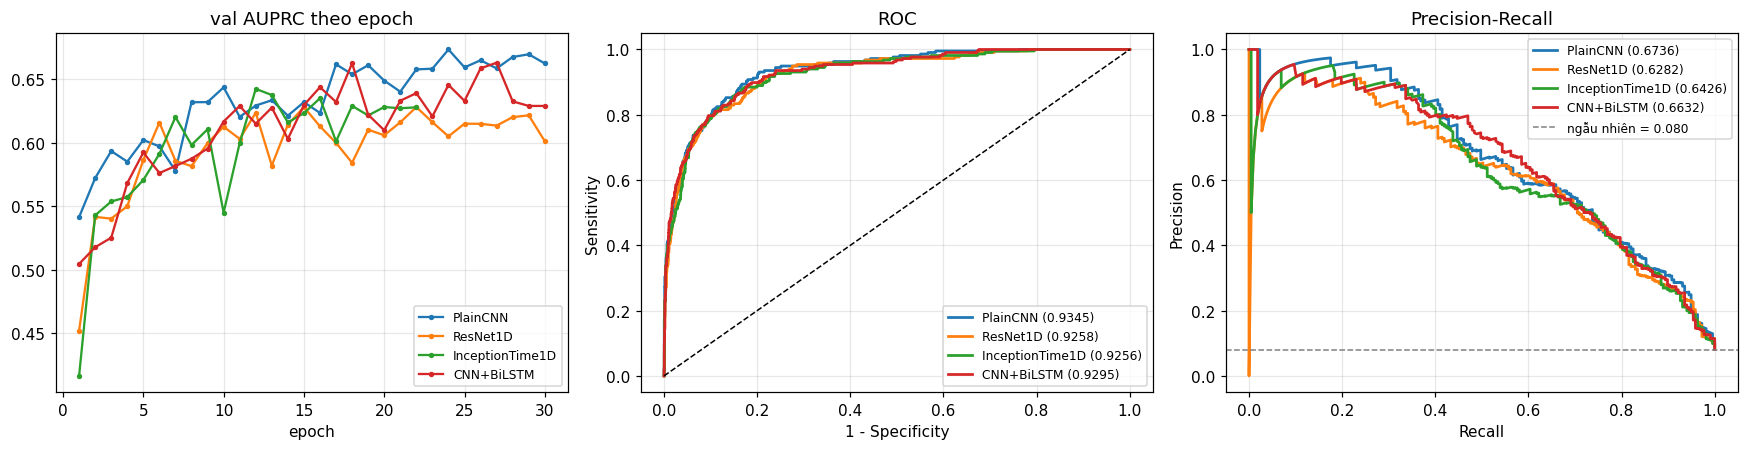

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

for name, r in RESULTS.items():
    if "hist" not in r:      # các dòng ensemble không có lịch sử train riêng
        continue
    h = pd.DataFrame(r["hist"])
    ax[0].plot(h.epoch, h.val_auprc, marker="o", ms=2.5, label=name)
ax[0].set_title("val AUPRC theo epoch"); ax[0].set_xlabel("epoch")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

base = float(np.mean(next(iter(RESULTS.values()))["y"]))
for name, r in RESULTS.items():
    if len(np.unique(r["y"].astype(int))) != 2:
        continue
    fpr, tpr, _ = roc_curve(r["y"], r["p"])
    ax[1].plot(fpr, tpr, lw=1.8, label=f"{name} ({r['metrics']['auroc']:.4f})")
    prec, rec, _ = precision_recall_curve(r["y"], r["p"])
    ax[2].plot(rec, prec, lw=1.8, label=f"{name} ({r['metrics']['auprc']:.4f})")

ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].set_xlabel("1 - Specificity"); ax[1].set_ylabel("Sensitivity")
ax[1].set_title("ROC"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

ax[2].axhline(base, ls="--", c="gray", lw=1, label=f"ngẫu nhiên = {base:.3f}")
ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision")
ax[2].set_title("Precision-Recall"); ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)

plt.tight_layout()
plt.show()

## 17. Lưu ý khi kết luận

**`AiTiAMI` là tái hiện theo mô tả kiến trúc, không phải model gốc của Medical AI Co.** (xem cảnh
báo ở mục 12). Không dùng kết quả của nó trong notebook này để phát biểu gì về hiệu năng của sản
phẩm thương mại thật — nó chỉ là một biến thể ResNet1D sâu/rộng hơn trong bộ so sánh.

**Ensemble WBF không đảm bảo luôn thắng model tốt nhất đơn lẻ.** Nếu các model mắc cùng loại lỗi
(cùng bị nhầm ở những ca khó giống nhau), hợp nhất xác suất sẽ không thêm được thông tin mới — đó
là kết quả hợp lệ cần báo cáo trung thực, không phải lý do chỉnh trọng số để "ép" ensemble thắng.

**Đừng đọc chênh lệch nhỏ như một cải thiện thật.** Seed đã cố định, nhưng `cudnn.benchmark` và AMP
khiến mỗi lần chạy lại lệch khoảng **±0,015 AUROC**. Chạy lặp lại cùng một notebook đã cho AUROC
STEMI dao động 0,9232 → 0,9362. Vì vậy hai mô hình/ensemble cách nhau dưới ~0,015 AUROC nên coi là
**ngang nhau**, không phải cái này hơn cái kia.

Muốn kết luận chắc chắn thì phải chạy nhiều seed cho mỗi kiến trúc rồi so trung bình ± độ lệch
chuẩn. Notebook này chạy một seed nên chỉ đủ để **loại bỏ** những kiến trúc kém hẳn, chưa đủ để
xếp hạng những cái sát nhau.

**Chỉ có một lần chia train/val**, chưa cross-validation, nên khoảng tin cậy của các metric chưa
được ước lượng.

**Tập test ẩn 10% không được đụng tới** ở bất kỳ bước nào — cả việc chọn mô hình lẫn chọn ngưỡng đều
làm trên validation.

---

## 18. Chuyển từ chạy thử sang chạy thật

Ở **mục 2**, đổi `RUN_MODE = "debug"` thành `RUN_MODE = "full"` rồi **Run all**.

Chế độ `full` train cả mười mô hình trên 17.960 bản ghi, tối đa 30 epoch mỗi mô hình — khoảng
**35–50 phút** trên GPU rời, **1,5–2,5 giờ** trên Colab T4 (hơn hai lần rưỡi so với bản 4 mô hình
trước đây, vì `Transformer1D`/`AiTiAMI` nặng hơn đáng kể so với bốn model gốc).

Notebook này dùng chung file cache với `01_stemi_classifier.ipynb`, nên nếu bạn đã chạy notebook kia ở chế độ
`full` trước thì bước tiền xử lý được bỏ qua hoàn toàn.

**Nếu phiên Colab đứt giữa chừng:** Run all lại. Những mô hình đã train xong được nạp từ checkpoint
và bỏ qua, chỉ train tiếp phần còn thiếu.